In [1]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/SantanderCS'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
import numpy as np
import pandas as pd
from lightgbm            import LGBMClassifier
from sklearn.metrics     import classification_report, roc_auc_score, f1_score, recall_score
from utils.preprocessing import load_data, split_features_target, scale_data, data_split, remove_zero_columns2
from utils.user_utils    import get_model_train_eval
from utils.feature_engineering import add_statistical_features, drop_highly_correlated_features

In [2]:
# 데이터 로딩 및 기본 전처리
train, test = load_data()
X_features, y_labels = split_features_target(train)
X_test = test.drop(columns=['ID'], axis=1)

In [3]:
# zero_count_rate 제거했을때 corr()에서 제거될 컬럼수 149개 잔존
X_features, X_test = remove_zero_columns2(X_features, X_test, 0.99)


Train Data Analysis (Threshold: 99.0% )
Train rows: 76,020, columns: 369
Test rows: 75,818, columns: 369

                                   Train Summary (zero_count 내림차순)                                    
                   ColumnName  na_Sum  nUnique          mode  modeFreq modeFreqRate  zero_count zero_count_rate_display
saldo_medio_var13_medio_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
                     ind_var2       0        1      0.000000     76020      100.00%       76020                 100.00%
        num_reemb_var33_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
    num_trasp_var17_out_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
    num_trasp_var33_out_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
              saldo_var2_ult1       0        1      0.000000     76020

In [4]:
print(X_features.shape)

# var3 처리
X_features['var3'] = X_features['var3'].replace(-999999, 2)

(76020, 149)


In [5]:
# add_statistical_features() before corr
X_features = add_statistical_features(X_features)
X_test     = add_statistical_features(X_features)

In [6]:
X_features.describe()

,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var41_comer_ult1,imp_op_var41_comer_ult3,imp_op_var41_efect_ult1,imp_op_var41_efect_ult3,imp_op_var41_ult1,...,saldo_medio_var13_corto_ult1,saldo_medio_var13_corto_ult3,var38,sum,mean,std,max,min,zero_count,negative_count
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,7.602000e+04,7.602000e+04,7.602000e+04,7.602000e+04,7.602000e+04,76020.000000,76020.000000,76020.000000
mean,2.716483,33.212865,86.208265,72.363067,119.529632,68.803937,113.056934,68.205140,113.225058,137.242763,...,4852.261814,3857.848542,1.172358e+05,3.036038e+08,3.267067e+06,2.601180e+07,3.036038e+08,-0.513415,117.643883,0.075033
std,9.447971,12.956486,1614.757313,339.315831,546.266294,319.605516,512.154823,531.897917,950.086398,697.712596,...,31886.615189,25572.245055,1.826646e+05,4.332354e+09,4.662025e+07,3.711796e+08,4.332354e+09,29.648464,17.518151,0.482995
min,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,5.163750e+03,2.212640e+04,2.383719e+02,1.897956e+03,2.212640e+04,-4942.260000,28.000000,0.000000
25%,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,6.787061e+04,2.287371e+05,2.463927e+03,1.996978e+04,2.287371e+05,0.000000,108.000000,0.000000
50%,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.064092e+05,3.673392e+05,3.956928e+03,3.215053e+04,3.673392e+05,0.000000,122.000000,0.000000
75%,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.187563e+05,4.675463e+05,5.035421e+03,4.069147e+04,4.675463e+05,0.000000,131.000000,0.000000
max,238.000000,105.000000,210000.000000,12888.030000,21024.810000,12888.030000,16566.810000,45990.000000,131100.000000,47598.090000,...,450000.000000,450000.000000,2.203474e+07,6.226867e+10,6.700699e+08,5.334877e+09,6.226867e+10,0.000000,147.000000,7.000000


In [7]:
print(X_features.shape, X_test.shape)

(76020, 156) (76020, 156)


In [8]:
# 상관계수 높은 feature들 삭제하기
X_features_dropped, drop_columns_train = drop_highly_correlated_features(X_features)
X_test_dropped, drop_colums_test = drop_highly_correlated_features(X_test)


In [9]:
print(X_features_dropped.shape, X_test_dropped.shape)

(76020, 99) (76020, 99)


In [10]:
# 삭제된 컬럼 개수 확인
print("Train에서 삭제된 컬럼 개수:", len(drop_columns_train))
print("Test에서 삭제된 컬럼 개수:", len(drop_colums_test))

# 동일 여부 확인
same = set(drop_columns_train) == set(drop_colums_test)
print("Train과 Test에서 삭제된 컬럼 동일 여부:", same)

# 교집합과 차집합 확인
print("공통으로 삭제된 컬럼:", set(drop_columns_train) & set(drop_colums_test))
print("Train에서만 삭제된 컬럼:", set(drop_columns_train) - set(drop_colums_test))
print("Test에서만 삭제된 컬럼:", set(drop_colums_test) - set(drop_columns_train))

Train에서 삭제된 컬럼 개수: 57
Test에서 삭제된 컬럼 개수: 57
Train과 Test에서 삭제된 컬럼 동일 여부: True
공통으로 삭제된 컬럼: {'ind_var37', 'max', 'num_meses_var13_corto_ult3', 'saldo_medio_var13_corto_ult1', 'imp_op_var39_efect_ult1', 'imp_op_var39_efect_ult3', 'mean', 'std', 'num_var8', 'num_var12', 'num_var24_0', 'num_var25', 'num_op_var39_ult1', 'num_var13_corto', 'num_var35', 'saldo_var42', 'saldo_medio_var12_ult1', 'num_var41_0', 'saldo_var24', 'num_var5', 'num_var13_corto_0', 'ind_var40_0', 'num_var37', 'num_op_var39_efect_ult1', 'num_op_var39_efect_ult3', 'num_var24', 'ind_var25_0', 'num_var13', 'num_op_var39_hace2', 'num_op_var39_ult3', 'delta_num_aport_var13_1y3', 'num_var45_ult3', 'ind_var26_cte', 'ind_var13', 'num_meses_var12_ult3', 'num_var1_0', 'ind_var25', 'num_op_var41_comer_ult3', 'num_op_var41_comer_ult1', 'ind_var41_0', 'num_var13_0', 'sum', 'num_var8_0', 'saldo_medio_var13_corto_ult3', 'num_var26', 'saldo_var25', 'saldo_medio_var12_ult3', 'num_var25_0', 'imp_op_var39_ult1', 'imp_op_var41_comer_ult1', '

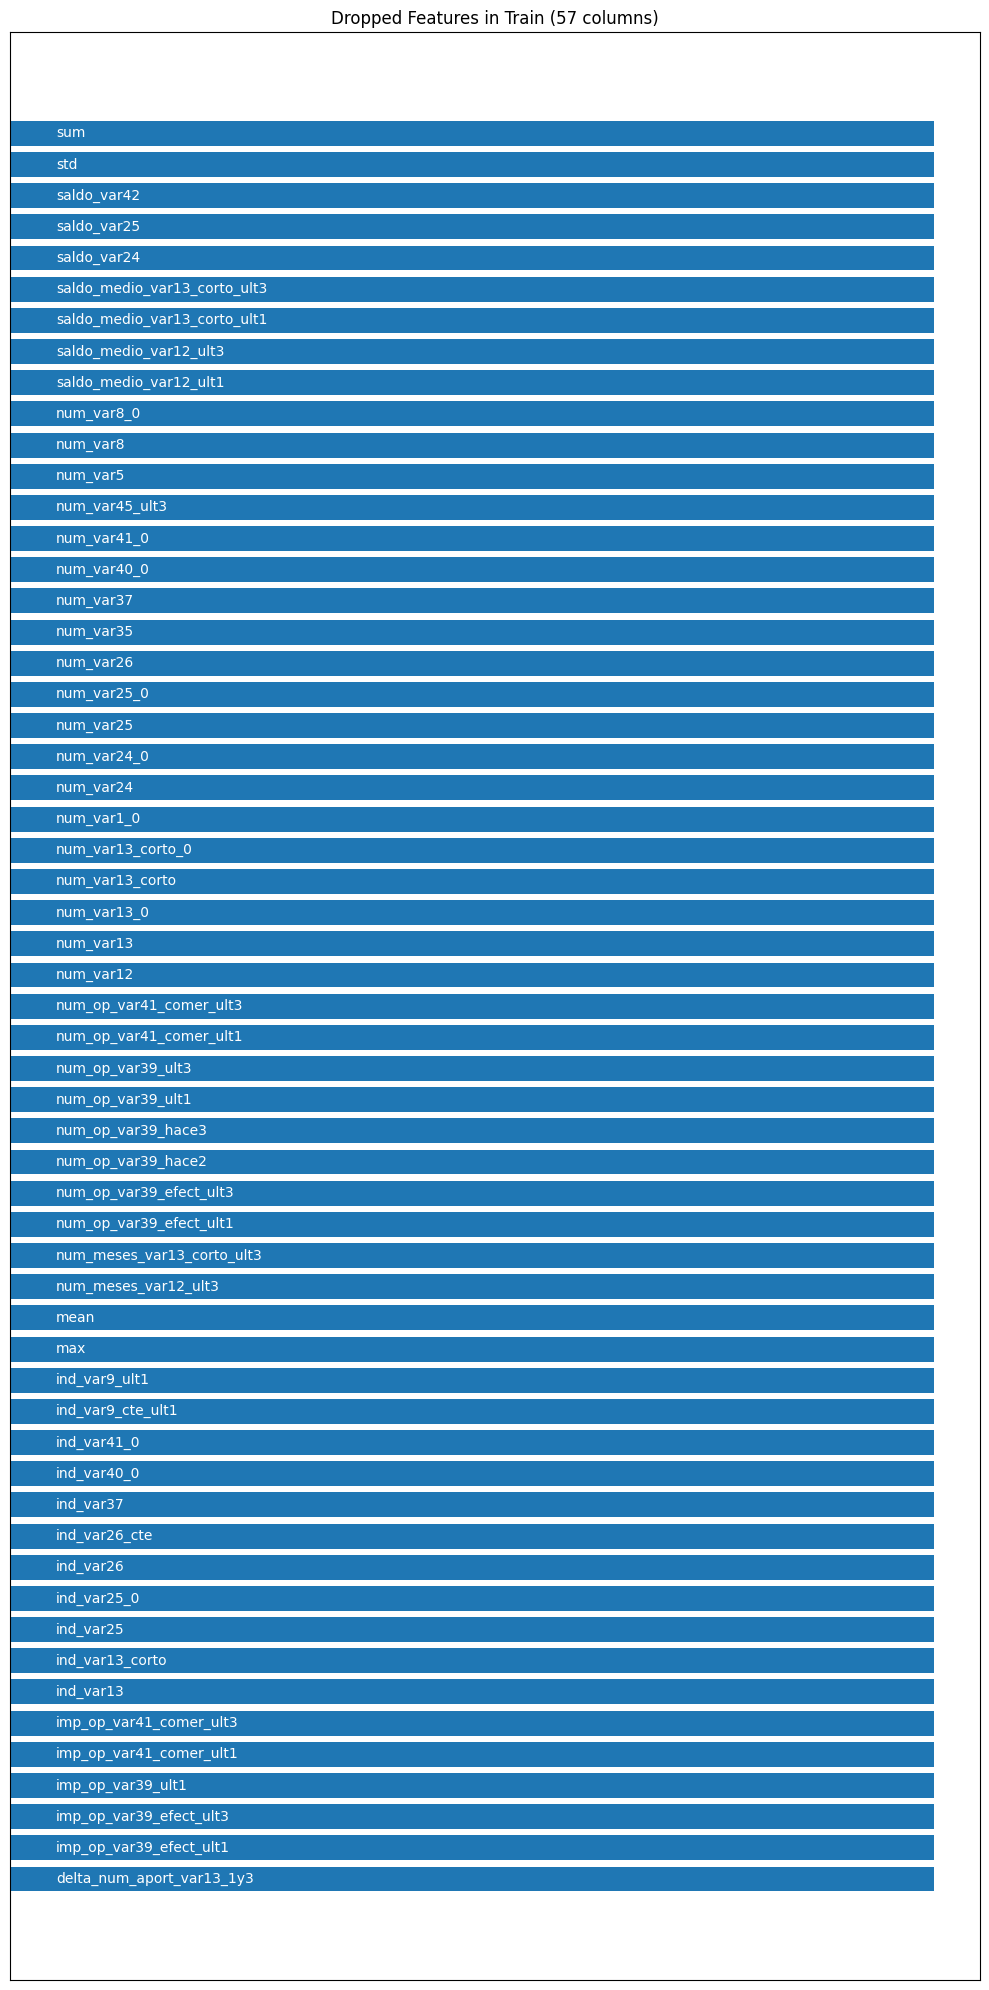

In [11]:
# 삭제 컬럼 시각화 
import matplotlib.pyplot as plt

sorted_cols = sorted(drop_columns_train)

y_pos = range(len(sorted_cols))

plt.figure(figsize=(10, 20))
bars = plt.barh(y_pos, [1]*len(sorted_cols))

# 바 안쪽 왼쪽에 컬럼명 표시
for bar, label in zip(bars, sorted_cols):
    plt.text(
        0.05,                               # 바 안쪽 왼쪽 여백
        bar.get_y() + bar.get_height()/2,   # 세로 중앙
        label,
        ha="left", va="center", fontsize=10, color="white"
    )

plt.yticks([])  # y축 tick 제거
plt.xticks([])  # x축 tick 제거
plt.title(f"Dropped Features in Train ({len(sorted_cols)} columns)")
plt.tight_layout()
plt.show()


In [12]:
for i, col in enumerate(sorted(drop_columns_train), start=1):
    print(f"{i:>2} : {col}")


 1 : delta_num_aport_var13_1y3
 2 : imp_op_var39_efect_ult1
 3 : imp_op_var39_efect_ult3
 4 : imp_op_var39_ult1
 5 : imp_op_var41_comer_ult1
 6 : imp_op_var41_comer_ult3
 7 : ind_var13
 8 : ind_var13_corto
 9 : ind_var25
10 : ind_var25_0
11 : ind_var26
12 : ind_var26_cte
13 : ind_var37
14 : ind_var40_0
15 : ind_var41_0
16 : ind_var9_cte_ult1
17 : ind_var9_ult1
18 : max
19 : mean
20 : num_meses_var12_ult3
21 : num_meses_var13_corto_ult3
22 : num_op_var39_efect_ult1
23 : num_op_var39_efect_ult3
24 : num_op_var39_hace2
25 : num_op_var39_hace3
26 : num_op_var39_ult1
27 : num_op_var39_ult3
28 : num_op_var41_comer_ult1
29 : num_op_var41_comer_ult3
30 : num_var12
31 : num_var13
32 : num_var13_0
33 : num_var13_corto
34 : num_var13_corto_0
35 : num_var1_0
36 : num_var24
37 : num_var24_0
38 : num_var25
39 : num_var25_0
40 : num_var26
41 : num_var35
42 : num_var37
43 : num_var40_0
44 : num_var41_0
45 : num_var45_ult3
46 : num_var5
47 : num_var8
48 : num_var8_0
49 : saldo_medio_var12_ult1
50 : sal

In [13]:
# 리스트를 Pandas Series로 변환
series = pd.Series(sorted(drop_columns_train), name="Dropped_Columns")

# CSV 파일로 저장
series.to_csv("../data/99perFeatureEngDroppedColumns_20251122.xls", index=False)

In [14]:
# 스케일링
# X_train_scaled, X_test_scaled, scaler = scale_data(X_features, X_test)

# 학습/테스트 데이터 분리
X_train, X_val, y_train, y_val = data_split(
  X_features, 
  # X_train_scaled,
  y_labels,
)

In [ ]:
model_name = 'LightGBM_99per_FE_Notscaled_ne500_nl23_mcs18_classweight15_lr05_ss08'


lgbm_clf = LGBMClassifier(
    random_state      = 0,  # 랜덤 시드 고정 → 동일 데이터면 같은 결과 재현
    n_estimators      = 500, # 부스팅 반복 횟수(트리 개수), 많으면 학습 충분, 적으면 부족
    num_leaves        = 32, # 하나 트리의 최대 잎사귀 수 → 트리 복잡도 조절          
    min_child_samples = 18, # 리프 하나가 가져야 할 최소 샘플 수 → 과적합 방지, 양성 샘플 확보            
    class_weight      = {0:1, 1:5}, # 불균형 데이터에서 양성 클래스(1)에 가중치 부여 → 재현율 향상
    learning_rate     = 0.05, # 학습률 → 낮으면 안정적, 많으면 빠르지만 과적합 가능
    subsample         = 0.8, # 행(row) 샘플링 비율 → 과적합 방지, 트리 다양성 증가
    colsample_bytree  = 0.8, # 열(feature) 샘플링 비율 → 과적합 방지, 트리 다양성 증가
    verbose           = -1 
)

# 함수 이용
get_model_train_eval(lgbm_clf, model_name, X_train, X_val, y_train, y_val)
result_text = '''
Scaled
✓ 모델 저장 완료: ../models\LightGBM_99per_FE_scaled_ne500_nl23_mcs18_classweight15_lr05_ss08.pkl
  파일 크기: 1.71 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8364, 정확도: 0.9284, 정밀도: 0.2393, 재현율: 0.3704, F1: 0.2907
오차행렬:
[[13893   709]
 [  379   223]]
실행 시간: 3.73996901512146

NotScaled
✓ 모델 저장 완료: ../models\LightGBM_99per_FE_Notscaled_ne500_nl23_mcs18_classweight15_lr05_ss08.pkl
  파일 크기: 1.71 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8364, 정확도: 0.9284, 정밀도: 0.2393, 재현율: 0.3704, F1: 0.2907
오차행렬:
[[13893   709]
 [  379   223]]
실행 시간: 3.6374640464782715
'''

✓ 모델 저장 완료: ../models\LightGBM_99per_FE_Notscaled_ne500_nl23_mcs18_classweight15_lr05_ss08.pkl
  파일 크기: 1.71 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8364, 정확도: 0.9284, 정밀도: 0.2393, 재현율: 0.3704, F1: 0.2907
오차행렬:
[[13893   709]
 [  379   223]]
실행 시간: 3.6374640464782715
